<a href="https://colab.research.google.com/github/vanan10700/doancoso/blob/main/codedoancoso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List, Tuple, Set, Dict, Optional
import time, warnings, copy
warnings.filterwarnings("ignore")

try:
    plt.rcParams["font.family"] = "DejaVu Sans"
except Exception:
    pass

print("  Imports thành công!")


  Imports thành công!


In [8]:

@dataclass
class Config:
    """Toàn bộ siêu tham số của bài toán."""
    grid_size: int        = 20
    num_stations: int     = 12
    coverage_radius: float = 3.5
    num_routes: int       = 6

    alpha: float = 1.0
    beta: float  = 0.6
    gamma: float = 2.5

    gto_max_iter: int = 25
    random_trials: int = 100

    seed: int = 42

cfg = Config()
print(f"📐  Grid {cfg.grid_size}×{cfg.grid_size}  |  "
      f"Stations {cfg.num_stations}  |  "
      f"α={cfg.alpha}  β={cfg.beta}  γ={cfg.gamma}")

📐  Grid 20×20  |  Stations 12  |  α=1.0  β=0.6  γ=2.5


In [9]:

class CityGrid:
    """
    Mô hình thành phố trên lưới 2-D.
    Bao gồm: bản đồ nhu cầu (demand), công suất lưới điện,
    và các tuyến đường chính (routes).
    """

    def __init__(self, config: Config):
        self.cfg = config
        self.n   = config.grid_size
        np.random.seed(config.seed)

        self.demand        = self._gen_demand()
        self.grid_capacity = self._gen_capacity()
        self.routes        = self._gen_routes()
        self.route_map     = self._build_route_map()

    def _gen_demand(self) -> np.ndarray:
        dem = np.zeros((self.n, self.n))
        n_centers = np.random.randint(3, 6)
        for _ in range(n_centers):
            cx, cy = np.random.randint(2, self.n - 2, size=2)
            intensity = np.random.uniform(6, 16)
            sigma     = np.random.uniform(2.5, 5.5)
            for i in range(self.n):
                for j in range(self.n):
                    d = np.sqrt((i - cx)**2 + (j - cy)**2)
                    dem[i, j] += intensity * np.exp(-d**2 / (2 * sigma**2))
        dem += np.random.uniform(0.5, 2.0, (self.n, self.n))
        return dem

    def _gen_capacity(self) -> np.ndarray:
        cap = np.full((self.n, self.n), 2, dtype=float)

        for _ in range(4):
            cx, cy = np.random.randint(0, self.n, 2)
            r = np.random.randint(2, 5)
            for i in range(max(0, cx-r), min(self.n, cx+r+1)):
                for j in range(max(0, cy-r), min(self.n, cy+r+1)):
                    cap[i, j] = np.random.randint(3, 6)

        for _ in range(3):
            cx, cy = np.random.randint(0, self.n, 2)
            r = np.random.randint(1, 3)
            for i in range(max(0, cx-r), min(self.n, cx+r+1)):
                for j in range(max(0, cy-r), min(self.n, cy+r+1)):
                    cap[i, j] = 1
        return cap

    def _gen_routes(self) -> List[Set[Tuple[int,int]]]:
        routes = []
        for _ in range(self.cfg.num_routes):
            s = tuple(np.random.randint(0, self.n, 2))
            e = tuple(np.random.randint(0, self.n, 2))
            spine = self._bresenham(s, e)
            wide  = set()
            for (x, y) in spine:
                for dx in (-1, 0, 1):
                    for dy in (-1, 0, 1):
                        nx, ny = x + dx, y + dy
                        if 0 <= nx < self.n and 0 <= ny < self.n:
                            wide.add((nx, ny))
            routes.append(wide)
        return routes

    @staticmethod
    def _bresenham(s, e):
        x0, y0 = s;  x1, y1 = e
        cells = []
        dx, dy = abs(x1-x0), abs(y1-y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy
        while True:
            cells.append((x0, y0))
            if x0 == x1 and y0 == y1:
                break
            e2 = 2 * err
            if e2 > -dy:  err -= dy;  x0 += sx
            if e2 <  dx:  err += dx;  y0 += sy
        return cells

    def _build_route_map(self):
        rm = [[set() for _ in range(self.n)] for _ in range(self.n)]
        for idx, route in enumerate(self.routes):
            for (x, y) in route:
                rm[x][y].add(idx)
        return rm


city = CityGrid(cfg)
print(f"🏙️  Thành phố đã được sinh:  demand range "
      f"[{city.demand.min():.1f}, {city.demand.max():.1f}]  |  "
      f"{len(city.routes)} tuyến đường")

🏙️  Thành phố đã được sinh:  demand range [1.1, 24.4]  |  6 tuyến đường


In [10]:

class GlobalReward:
    """
    F(S) = α · Coverage(S) + β · Synergy(S) − γ · Penalty(S)

    • Coverage  (SUBMODULAR)  : weighted set-cover.
    • Synergy   (SUPERMODULAR): bonus cộng hưởng trên tuyến đường.
    • Penalty   (MODULAR)     : phạt vượt công suất lưới điện.
    """

    def __init__(self, city: CityGrid, config: Config):
        self.city = city
        self.cfg  = config

        self._cov_cache: Dict[Tuple[int,int], Set[Tuple[int,int]]] = {}
        r = config.coverage_radius
        for i in range(city.n):
            for j in range(city.n):
                cells = set()
                for ii in range(max(0, int(i - r)), min(city.n, int(i + r + 1))):
                    for jj in range(max(0, int(j - r)), min(city.n, int(j + r + 1))):
                        if np.sqrt((ii - i)**2 + (jj - j)**2) <= r:
                            cells.add((ii, jj))
                self._cov_cache[(i, j)] = cells


    def coverage(self, S: Set[Tuple[int,int]]) -> float:
        """Tổng demand tại các cell được phủ bởi ít nhất 1 trạm."""
        covered: Set[Tuple[int,int]] = set()
        for loc in S:
            covered |= self._cov_cache[loc]
        return sum(self.city.demand[x, y] for (x, y) in covered)

    def synergy(self, S: Set[Tuple[int,int]]) -> float:
        """
        Thưởng khi ≥2 trạm cùng nằm trên 1 tuyến đường.
        f(k) = k² − k  (hàm lồi → supermodular)
        Ý nghĩa: Hành lang sạc dọc cao tốc giá trị hơn trạm đơn lẻ.
        """
        if len(S) < 2:
            return 0.0
        route_cnt = [0] * len(self.city.routes)
        for (x, y) in S:
            for ri in self.city.route_map[x][y]:
                route_cnt[ri] += 1
        return float(sum(k * k - k for k in route_cnt if k >= 2))

    def safety_penalty(self, S: Set[Tuple[int,int]]) -> float:
        """Phạt khi tải lưới điện vượt quá công suất cho phép."""
        load = np.zeros((self.city.n, self.city.n))
        for (x, y) in S:
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < self.city.n and 0 <= ny < self.city.n:
                        load[nx, ny] += 1.0
        excess = np.maximum(0.0, load - self.city.grid_capacity)
        return float(np.sum(excess))

    def compute(self, S: Set[Tuple[int,int]]) -> float:
        c = self.cfg
        return (c.alpha * self.coverage(S)
              + c.beta  * self.synergy(S)
              - c.gamma * self.safety_penalty(S))

    def compute_detailed(self, S: Set[Tuple[int,int]]) -> Dict[str, float]:
        c = self.cfg
        cov = self.coverage(S)
        syn = self.synergy(S)
        pen = self.safety_penalty(S)
        return dict(
            coverage=cov, synergy=syn, penalty=pen,
            coverage_w=c.alpha * cov,
            synergy_w=c.beta  * syn,
            penalty_w=c.gamma * pen,
            total=c.alpha * cov + c.beta * syn - c.gamma * pen,
        )

    def marginal_gain(self, S: Set[Tuple[int,int]],
                      loc: Tuple[int,int]) -> float:
        """F(S ∪ {loc}) − F(S)"""
        if loc in S:
            return 0.0
        return self.compute(S | {loc}) - self.compute(S)


reward_fn = GlobalReward(city, cfg)
print("  GlobalReward đã khởi tạo (coverage cache ready)")



✅  GlobalReward đã khởi tạo (coverage cache ready)


In [11]:

class SubmodularSemiGradient:
    """
    Tính Modular Lower Bound (Semi-gradient / Subgradient) của F
    tại tập hiện tại S₀.

    Với mỗi vị trí loc trên lưới:
      • loc ∈ S₀  →  w(loc) = F(S₀) − F(S₀ \\ {loc})
                      (chi phí nếu mất trạm này)
      • loc ∉ S₀  →  w(loc) = F(S₀ ∪ {loc}) − F(S₀)
                      (lợi ích nếu thêm trạm này)

    Modular lower bound:
        m_{S₀}(S) = const + Σ_{loc ∈ S} w(loc)
    Đảm bảo: m_{S₀}(S) ≤ F(S)  ∀S   và   m_{S₀}(S₀) = F(S₀).
    """

    def __init__(self, reward_fn: GlobalReward, config: Config):
        self.reward_fn = reward_fn
        self.n = config.grid_size

    def compute_weights(
        self, current: Set[Tuple[int,int]]
    ) -> Dict[Tuple[int,int], float]:
        f_cur = self.reward_fn.compute(current)
        weights: Dict[Tuple[int,int], float] = {}

        for i in range(self.n):
            for j in range(self.n):
                loc = (i, j)
                if loc in current:

                    weights[loc] = f_cur - self.reward_fn.compute(current - {loc})
                else:

                    weights[loc] = self.reward_fn.compute(current | {loc}) - f_cur
        return weights


semi_grad = SubmodularSemiGradient(reward_fn, cfg)
print(" SubmodularSemiGradient đã khởi tạo")

✅  SubmodularSemiGradient đã khởi tạo


In [12]:

class GTOAgent:
    """
    Algorithm 1 – Global Trajectory Optimization.

    Luồng:
      1. Khởi tạo S₀ bằng Greedy.
      2. Lặp:
         a) Tính modular weights tại S_k  (Semi-gradient)
         b) Giải bài toán modular: chọn top-H vị trí theo w
         c) Nếu F(S_{k+1}) > F(S_k) → cập nhật
         d) Dừng khi hội tụ hoặc đạt max_iter.
    """

    def __init__(self, city: CityGrid, config: Config):
        self.city      = city
        self.cfg       = config
        self.reward_fn = GlobalReward(city, config)
        self.sg        = SubmodularSemiGradient(self.reward_fn, config)
        self.history: List[float] = []

    def _greedy_init(self) -> Set[Tuple[int,int]]:
        S: Set[Tuple[int,int]] = set()
        for step in range(self.cfg.num_stations):
            best_loc  = None
            best_gain = -np.inf
            for i in range(self.cfg.grid_size):
                for j in range(self.cfg.grid_size):
                    loc = (i, j)
                    if loc not in S:
                        g = self.reward_fn.marginal_gain(S, loc)
                        if g > best_gain:
                            best_gain = g
                            best_loc  = loc
            assert best_loc is not None
            S.add(best_loc)
        return S

    def optimize(self) -> Tuple[Set[Tuple[int,int]], List[float]]:
        t0 = time.time()
        print("🚀  GTO  ──  Bước 0: Khởi tạo Greedy …")
        current   = self._greedy_init()
        current_f = self.reward_fn.compute(current)
        self.history = [current_f]
        print(f"     Greedy init  F = {current_f:.2f}")

        for it in range(1, self.cfg.gto_max_iter + 1):
            # (a) Tính modular weights
            weights = self.sg.compute_weights(current)

            # (b) Giải bài toán modular: chọn H vị trí có w cao nhất
            ranked = sorted(weights, key=weights.get, reverse=True)
            candidate = set(ranked[: self.cfg.num_stations])

            # (c) Đánh giá
            cand_f = self.reward_fn.compute(candidate)

            if cand_f > current_f + 1e-6:
                delta = cand_f - current_f
                current, current_f = candidate, cand_f
                self.history.append(current_f)
                print(f"     Iter {it:>2d}   F = {current_f:.2f}  "
                      f"(+{delta:.2f}) ✓")
            else:
                self.history.append(current_f)
                elapsed = time.time() - t0
                print(f"     Iter {it:>2d}   Hội tụ.  "
                      f"Tổng thời gian: {elapsed:.1f}s")
                break

        return current, self.history

In [13]:

class RandomAgent:
    """Đặt trạm ngẫu nhiên, giữ lại lần tốt nhất."""

    def __init__(self, city: CityGrid, config: Config):
        self.reward_fn = GlobalReward(city, config)
        self.cfg = config

    def optimize(self) -> Tuple[Set[Tuple[int,int]], float]:
        all_locs = [(i, j)
                    for i in range(self.cfg.grid_size)
                    for j in range(self.cfg.grid_size)]
        best_S: Optional[Set[Tuple[int,int]]] = None
        best_f = -np.inf

        for _ in range(self.cfg.random_trials):
            idx = np.random.choice(len(all_locs),
                                   self.cfg.num_stations, replace=False)
            S = set(all_locs[i] for i in idx)
            f = self.reward_fn.compute(S)
            if f > best_f:
                best_f, best_S = f, S
        return best_S, best_f   # type: ignore


class GreedyAgent:
    """Mỗi bước chọn vị trí có marginal gain F cao nhất."""

    def __init__(self, city: CityGrid, config: Config):
        self.reward_fn = GlobalReward(city, config)
        self.cfg = config

    def optimize(self) -> Tuple[Set[Tuple[int,int]], float]:
        S: Set[Tuple[int,int]] = set()
        for _ in range(self.cfg.num_stations):
            best_loc  = None
            best_gain = -np.inf
            for i in range(self.cfg.grid_size):
                for j in range(self.cfg.grid_size):
                    loc = (i, j)
                    if loc not in S:
                        g = self.reward_fn.marginal_gain(S, loc)
                        if g > best_gain:
                            best_gain = g
                            best_loc  = loc
            assert best_loc is not None
            S.add(best_loc)
        return S, self.reward_fn.compute(S)


print("  Agents đã sẵn sàng (GTO / Greedy / Random)")

✅  Agents đã sẵn sàng (GTO / Greedy / Random)


In [20]:

def run_experiments(config: Config = None):
    if config is None:
        config = cfg

    city_      = CityGrid(config)
    reward_fn_ = GlobalReward(city_, config)

    print("=" * 62)
    print("  EV CHARGING STATION OPTIMIZATION  –  GLOBAL RL (GTO)")
    print("=" * 62)
    print(f"  Grid {config.grid_size}×{config.grid_size}  |  "
          f"H = {config.num_stations} trạm  |  "
          f"α={config.alpha}  β={config.beta}  γ={config.gamma}")
    print()

    # ---- Random ----
    print("  Random Agent  "
          f"({config.random_trials} trials) …")
    ra = RandomAgent(city_, config)
    rand_S, rand_f = ra.optimize()
    print(f"     Best F = {rand_f:.2f}\n")

    # ---- Greedy ----
    print("  Greedy Agent …")
    t0 = time.time()
    ga = GreedyAgent(city_, config)
    grdy_S, grdy_f = ga.optimize()
    print(f"     F = {grdy_f:.2f}   ({time.time()-t0:.1f}s)\n")

    # ---- GTO ----
    print("  GTO Agent …")
    gto = GTOAgent(city_, config)
    gto_S, gto_hist = gto.optimize()
    gto_f = reward_fn_.compute(gto_S)
    print()

    # ---- Tổng kết ----
    print("=" * 62)
    print("  BẢNG SO SÁNH KẾT QUẢ")
    print("=" * 62)
    header = (f"{'Phương pháp':<18}"
              f"{'F(S)':>9}"
              f"{'Coverage':>10}"
              f"{'Synergy':>9}"
              f"{'Penalty':>9}")
    print(header)
    print("-" * 55)
    for name, S in [("Random", rand_S),
                    ("Greedy", grdy_S),
                    ("GTO (Global RL)", gto_S)]:
        d = reward_fn_.compute_detailed(S)
        print(f"{name:<18}"
              f"{d['total']:>9.2f}"
              f"{d['coverage']:>10.2f}"
              f"{d['synergy']:>9.1f}"
              f"{d['penalty']:>9.1f}")

    # Phần trăm cải thiện GTO so với Greedy
    if grdy_f != 0:
        pct = (gto_f - grdy_f) / abs(grdy_f) * 100
        print(f"\n  GTO cải thiện so với Greedy: {pct:+.2f}%")

    return dict(
        city=city_, reward_fn=reward_fn_,
        random=dict(stations=rand_S,
                    detail=reward_fn_.compute_detailed(rand_S)),
        greedy=dict(stations=grdy_S,
                    detail=reward_fn_.compute_detailed(grdy_S)),
        gto=dict(stations=gto_S,
                 detail=reward_fn_.compute_detailed(gto_S),
                 history=gto_hist),
    )


results = run_experiments(cfg)

  EV CHARGING STATION OPTIMIZATION  –  GLOBAL RL (GTO)
  Grid 20×20  |  H = 12 trạm  |  α=1.0  β=0.6  γ=2.5

  Random Agent  (100 trials) …
     Best F = 3230.99

  Greedy Agent …
     F = 3717.03   (0.8s)

  GTO Agent …
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3717.03
     Iter  1   Hội tụ.  Tổng thời gian: 1.0s

  BẢNG SO SÁNH KẾT QUẢ
Phương pháp            F(S)  Coverage  Synergy  Penalty
-------------------------------------------------------
Random              3230.99   3217.79     22.0      0.0
Greedy              3717.03   3702.63     24.0      0.0
GTO (Global RL)     3717.03   3702.63     24.0      0.0

  GTO cải thiện so với Greedy: +0.00%


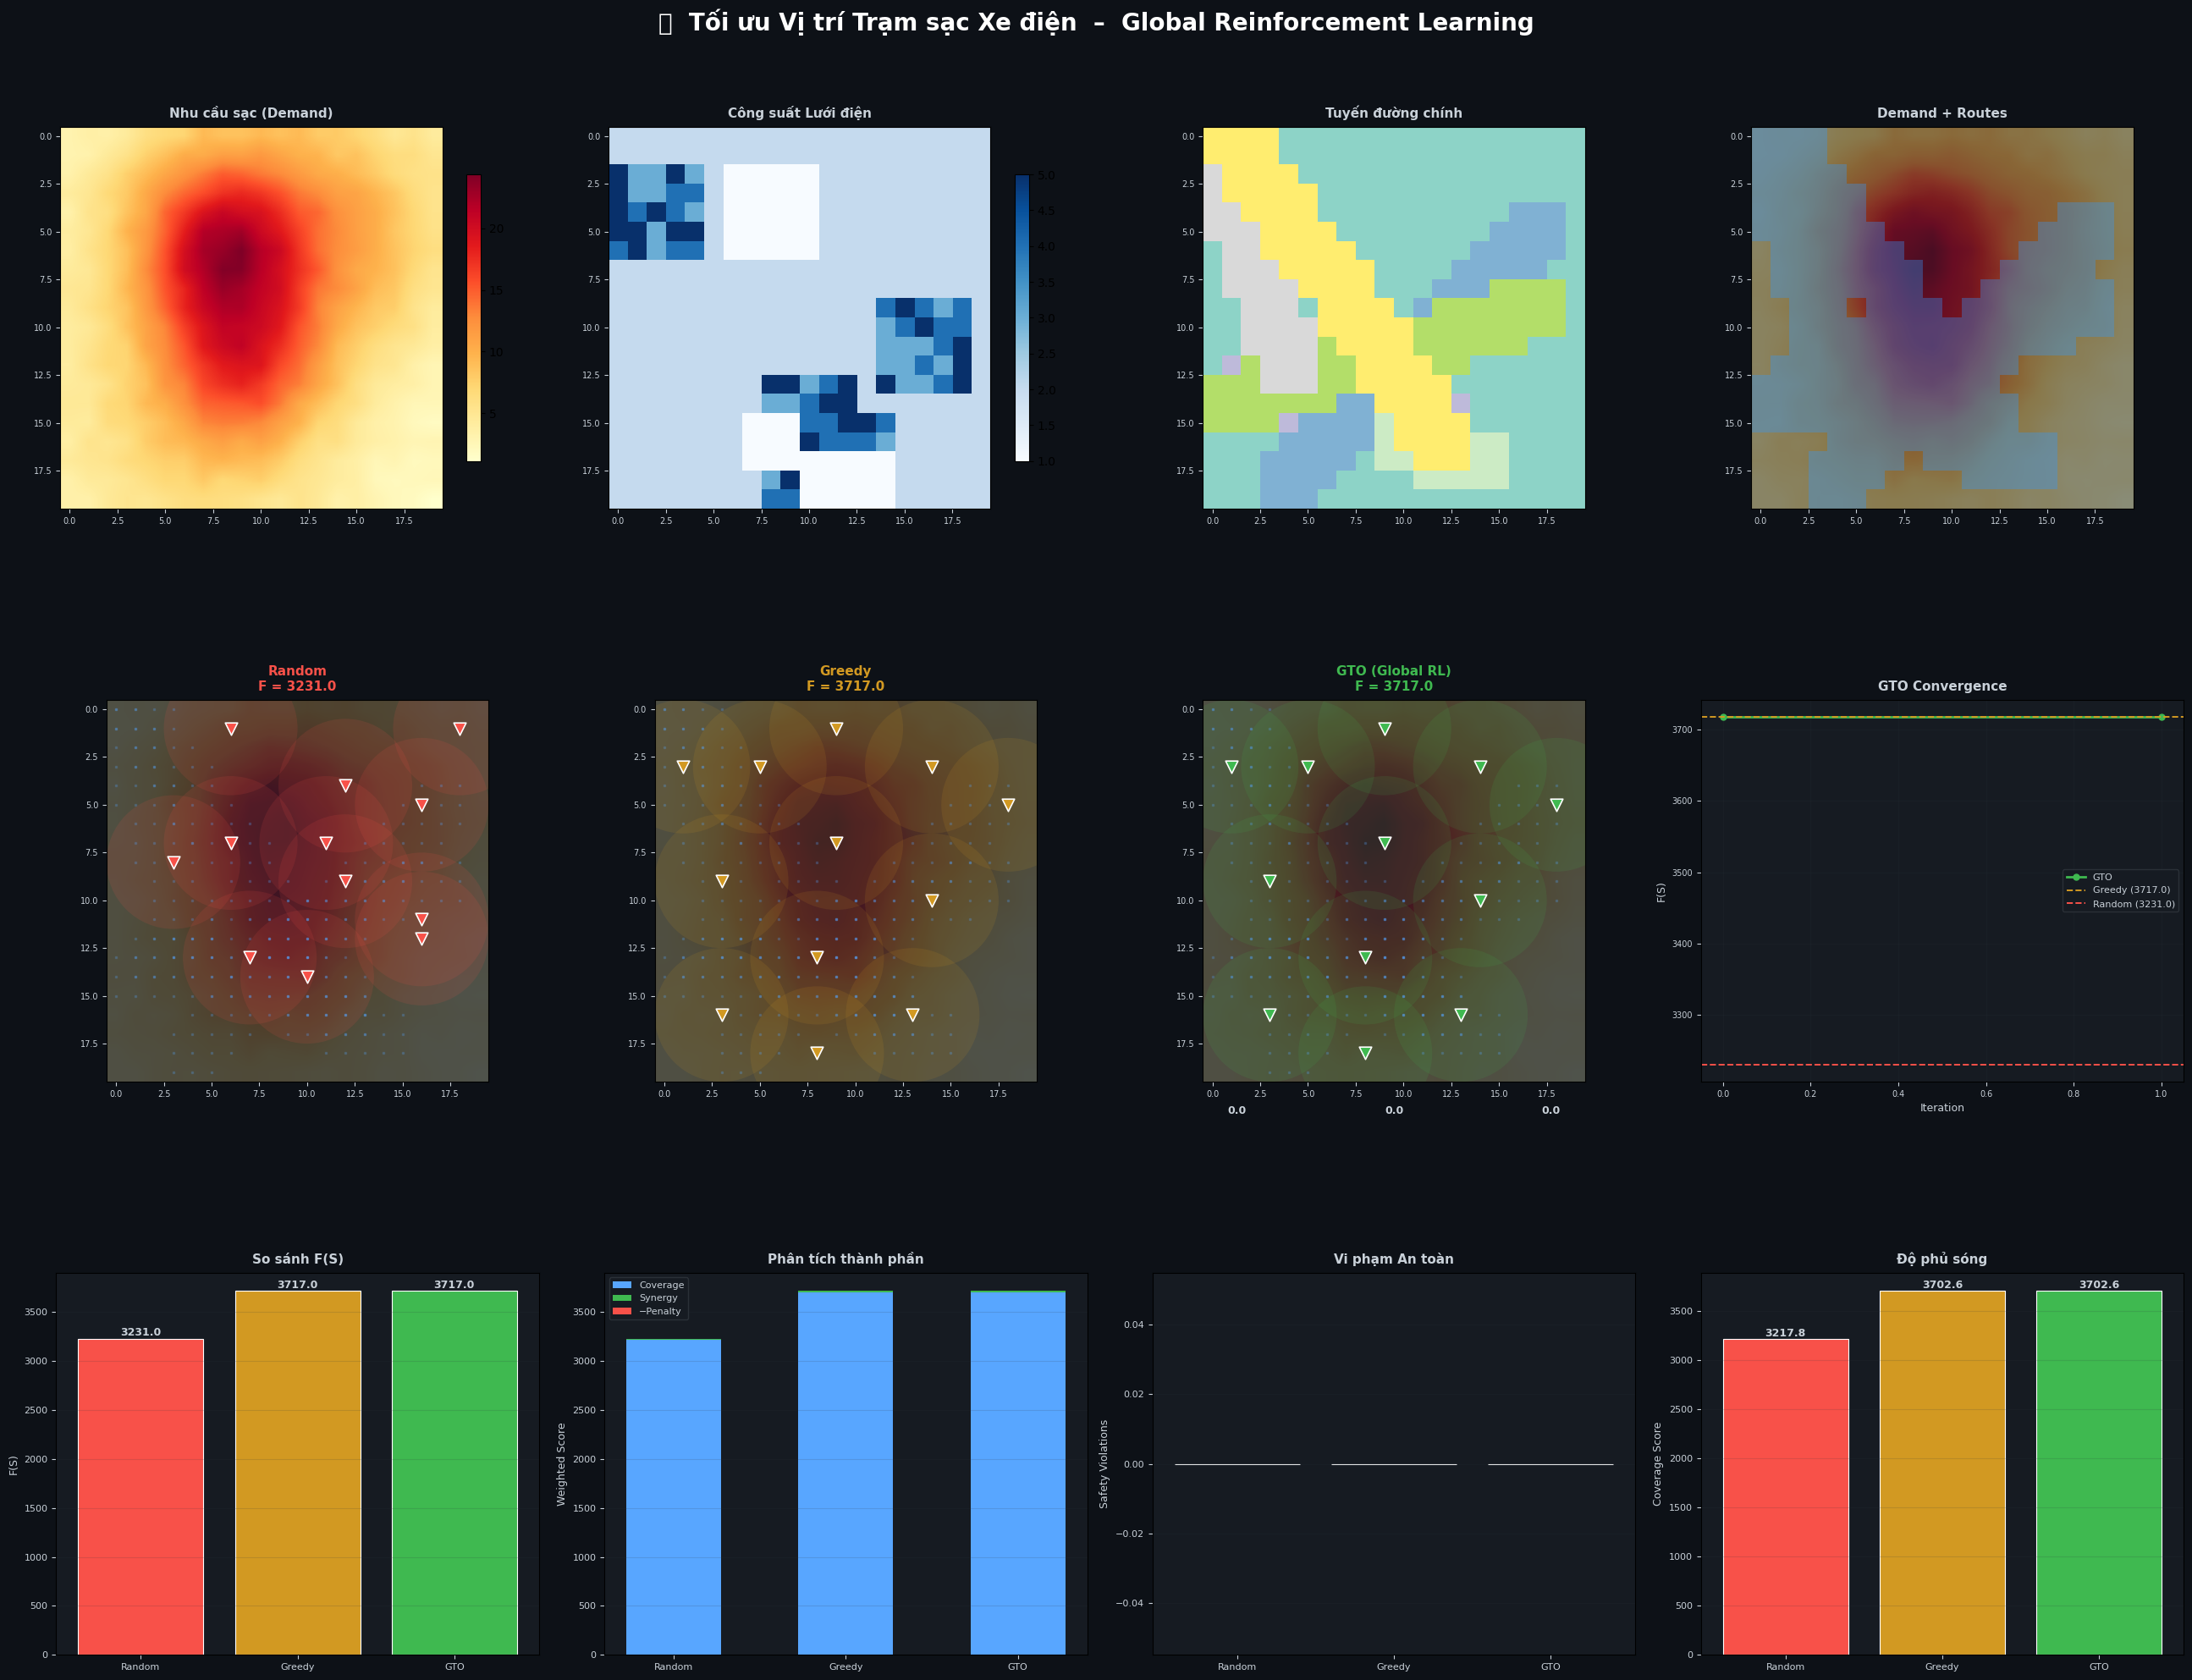


📊  Biểu đồ đã lưu → ev_charging_grl_results.png


In [15]:

def visualize(results: Dict, config: Config = None):
    if config is None:
        config = cfg
    city_      = results["city"]
    reward_fn_ = results["reward_fn"]
    n          = city_.n

    fig = plt.figure(figsize=(26, 20), facecolor="#0d1117")
    fig.suptitle(
        "  Tối ưu Vị trí Trạm sạc Xe điện  –  Global Reinforcement Learning",
        fontsize=20, fontweight="bold", color="white", y=0.99,
    )

    dark_bg  = "#0d1117"
    card_bg  = "#161b22"
    txt_clr  = "#c9d1d9"
    colors   = {"Random": "#f85149", "Greedy": "#d29922",
                "GTO (Global RL)": "#3fb950"}

    # ---------- Hàng 1: Bản đồ thành phố ----------
    map_titles = ["Nhu cầu sạc (Demand)", "Công suất Lưới điện",
                  "Tuyến đường chính", "Demand + Routes"]
    map_cmaps  = ["YlOrRd", "Blues", "Set3", "YlOrRd"]

    for idx in range(4):
        ax = fig.add_subplot(3, 4, idx + 1)
        ax.set_facecolor(card_bg)
        ax.set_title(map_titles[idx], color=txt_clr, fontsize=11,
                     fontweight="bold", pad=8)
        ax.tick_params(colors=txt_clr, labelsize=7)

        if idx == 0:
            im = ax.imshow(city_.demand, cmap="YlOrRd",
                           interpolation="bilinear")
            plt.colorbar(im, ax=ax, shrink=0.75)
        elif idx == 1:
            im = ax.imshow(city_.grid_capacity, cmap="Blues",
                           interpolation="nearest")
            plt.colorbar(im, ax=ax, shrink=0.75)
        elif idx == 2:
            rv = np.zeros((n, n))
            for ri, route in enumerate(city_.routes):
                for (x, y) in route:
                    rv[x, y] = ri + 1
            ax.imshow(rv, cmap="Set3", interpolation="nearest")
        else:
            ax.imshow(city_.demand, cmap="YlOrRd", alpha=0.5,
                      interpolation="bilinear")
            overlay = np.zeros((n, n, 4))
            for route in city_.routes:
                for (x, y) in route:
                    overlay[x, y] = [0.2, 0.6, 1.0, 0.35]
            ax.imshow(overlay)

    # ---------- Hàng 2: Vị trí trạm sạc ----------
    methods = [("Random",  results["random"]),
               ("Greedy",  results["greedy"]),
               ("GTO (Global RL)", results["gto"])]

    for idx, (name, data) in enumerate(methods):
        ax = fig.add_subplot(3, 4, 5 + idx)
        ax.set_facecolor(card_bg)
        ax.imshow(city_.demand, cmap="YlOrRd", alpha=0.25,
                  interpolation="bilinear")

        # Vẽ tuyến đường nền
        for route in city_.routes:
            for (x, y) in route:
                ax.plot(y, x, "s", color="#58a6ff", markersize=1.5,
                        alpha=0.2)

        # Vẽ vùng phủ sóng
        stations = data["stations"]
        clr = colors[name]
        for (sx, sy) in stations:
            circle = plt.Circle(
                (sy, sx), config.coverage_radius,
                color=clr, alpha=0.12, linewidth=0,
            )
            ax.add_patch(circle)

        # Vẽ trạm sạc
        xs = [s[1] for s in stations]
        ys = [s[0] for s in stations]
        ax.scatter(xs, ys, c=clr, s=110, marker="v",
                   edgecolors="white", linewidths=1.2, zorder=5)

        f_val = data["detail"]["total"]
        ax.set_title(f"{name}\nF = {f_val:.1f}", color=clr,
                     fontsize=11, fontweight="bold", pad=8)
        ax.set_xlim(-0.5, n - 0.5)
        ax.set_ylim(n - 0.5, -0.5)
        ax.tick_params(colors=txt_clr, labelsize=7)

    # ---------- Hàng 2 cột 4: Convergence ----------
    ax_cv = fig.add_subplot(3, 4, 8)
    ax_cv.set_facecolor(card_bg)
    hist = results["gto"]["history"]
    ax_cv.plot(range(len(hist)), hist, "o-", color="#3fb950",
               linewidth=2, markersize=5, label="GTO")
    grdy_f = results["greedy"]["detail"]["total"]
    rand_f = results["random"]["detail"]["total"]
    ax_cv.axhline(grdy_f, color="#d29922", ls="--", lw=1.4,
                  label=f"Greedy ({grdy_f:.1f})")
    ax_cv.axhline(rand_f, color="#f85149", ls="--", lw=1.4,
                  label=f"Random ({rand_f:.1f})")
    ax_cv.set_xlabel("Iteration", color=txt_clr, fontsize=9)
    ax_cv.set_ylabel("F(S)", color=txt_clr, fontsize=9)
    ax_cv.set_title("GTO Convergence", color=txt_clr, fontsize=11,
                    fontweight="bold", pad=8)
    ax_cv.legend(fontsize=8, facecolor=card_bg, edgecolor="#30363d",
                 labelcolor=txt_clr)
    ax_cv.grid(True, alpha=0.15, color="#30363d")
    ax_cv.tick_params(colors=txt_clr, labelsize=7)

    # ---------- Hàng 3: Biểu đồ phân tích ----------
    m_names = ["Random", "Greedy", "GTO"]
    m_keys  = ["random", "greedy", "gto"]
    bar_colors = ["#f85149", "#d29922", "#3fb950"]

    # 3-1  Tổng F(S)
    ax_b1 = fig.add_subplot(3, 4, 9)
    ax_b1.set_facecolor(card_bg)
    vals = [results[k]["detail"]["total"] for k in m_keys]
    bars = ax_b1.bar(m_names, vals, color=bar_colors,
                     edgecolor="white", linewidth=0.8)
    for b, v in zip(bars, vals):
        ax_b1.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                   f"{v:.1f}", ha="center", va="bottom",
                   color=txt_clr, fontweight="bold", fontsize=9)
    ax_b1.set_ylabel("F(S)", color=txt_clr, fontsize=9)
    ax_b1.set_title("So sánh F(S)", color=txt_clr, fontsize=11,
                    fontweight="bold", pad=8)
    ax_b1.tick_params(colors=txt_clr, labelsize=8)
    ax_b1.grid(axis="y", alpha=0.15, color="#30363d")

    # 3-2  Stacked: Coverage / Synergy / Penalty
    ax_b2 = fig.add_subplot(3, 4, 10)
    ax_b2.set_facecolor(card_bg)
    x_pos = np.arange(3)
    cov_w = [results[k]["detail"]["coverage_w"] for k in m_keys]
    syn_w = [results[k]["detail"]["synergy_w"]  for k in m_keys]
    pen_w = [-results[k]["detail"]["penalty_w"] for k in m_keys]
    ax_b2.bar(x_pos, cov_w, 0.55, label="Coverage", color="#58a6ff")
    ax_b2.bar(x_pos, syn_w, 0.55, bottom=cov_w,
              label="Synergy", color="#3fb950")
    ax_b2.bar(x_pos, pen_w, 0.55, label="−Penalty", color="#f85149")
    ax_b2.set_xticks(x_pos)
    ax_b2.set_xticklabels(m_names)
    ax_b2.set_ylabel("Weighted Score", color=txt_clr, fontsize=9)
    ax_b2.set_title("Phân tích thành phần", color=txt_clr, fontsize=11,
                    fontweight="bold", pad=8)
    ax_b2.legend(fontsize=8, facecolor=card_bg, edgecolor="#30363d",
                 labelcolor=txt_clr)
    ax_b2.tick_params(colors=txt_clr, labelsize=8)
    ax_b2.grid(axis="y", alpha=0.15, color="#30363d")

    # 3-3  Safety Violations
    ax_b3 = fig.add_subplot(3, 4, 11)
    ax_b3.set_facecolor(card_bg)
    pens = [results[k]["detail"]["penalty"] for k in m_keys]
    bars_p = ax_b3.bar(m_names, pens, color=bar_colors,
                       edgecolor="white", linewidth=0.8)
    for b, v in zip(bars_p, pens):
        ax_b3.text(b.get_x() + b.get_width() / 2,
                   b.get_height() + 0.1,
                   f"{v:.1f}", ha="center", va="bottom",
                   color=txt_clr, fontweight="bold", fontsize=9)
    ax_b3.set_ylabel("Safety Violations", color=txt_clr, fontsize=9)
    ax_b3.set_title("Vi phạm An toàn", color=txt_clr, fontsize=11,
                    fontweight="bold", pad=8)
    ax_b3.tick_params(colors=txt_clr, labelsize=8)
    ax_b3.grid(axis="y", alpha=0.15, color="#30363d")

    # 3-4  Coverage
    ax_b4 = fig.add_subplot(3, 4, 12)
    ax_b4.set_facecolor(card_bg)
    covs = [results[k]["detail"]["coverage"] for k in m_keys]
    bars_c = ax_b4.bar(m_names, covs, color=bar_colors,
                       edgecolor="white", linewidth=0.8)
    for b, v in zip(bars_c, covs):
        ax_b4.text(b.get_x() + b.get_width() / 2,
                   b.get_height() + 0.5,
                   f"{v:.1f}", ha="center", va="bottom",
                   color=txt_clr, fontweight="bold", fontsize=9)
    ax_b4.set_ylabel("Coverage Score", color=txt_clr, fontsize=9)
    ax_b4.set_title("Độ phủ sóng", color=txt_clr, fontsize=11,
                    fontweight="bold", pad=8)
    ax_b4.tick_params(colors=txt_clr, labelsize=8)
    ax_b4.grid(axis="y", alpha=0.15, color="#30363d")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("ev_charging_grl_results.png", dpi=150,
                bbox_inches="tight", facecolor=dark_bg)
    plt.show()
    print("\n📊  Biểu đồ đã lưu → ev_charging_grl_results.png")


visualize(results, cfg)

In [16]:

def detailed_analysis(results: Dict, config: Config = None):
    """In ra phân tích chi tiết cho từng phương pháp."""
    if config is None:
        config = cfg

    city_      = results["city"]
    reward_fn_ = results["reward_fn"]

    print("\n" + "=" * 62)
    print("🔎  PHÂN TÍCH CHI TIẾT")
    print("=" * 62)

    for name, key in [("Random", "random"),
                      ("Greedy", "greedy"),
                      ("GTO (Global RL)", "gto")]:
        d = results[key]["detail"]
        S = results[key]["stations"]
        print(f"\n{'─'*40}")
        print(f"  {name}")
        print(f"{'─'*40}")
        print(f"  Tổng F(S)          = {d['total']:.2f}")
        print(f"  Coverage (raw)     = {d['coverage']:.2f}")
        print(f"  Synergy  (raw)     = {d['synergy']:.1f}")
        print(f"  Penalty  (raw)     = {d['penalty']:.1f}")
        print(f"  Coverage ×α        = {d['coverage_w']:.2f}")
        print(f"  Synergy  ×β        = {d['synergy_w']:.2f}")
        print(f"  Penalty  ×γ        = {d['penalty_w']:.2f}")

        # Đếm trạm trên tuyến đường
        on_route = sum(1 for (x, y) in S
                       if len(city_.route_map[x][y]) > 0)
        print(f"  Trạm trên tuyến đường: {on_route}/{len(S)}")

        # Tổng demand được phủ
        covered = set()
        for loc in S:
            covered |= reward_fn_._cov_cache[loc]
        total_demand = np.sum(city_.demand)
        covered_demand = sum(city_.demand[x, y] for (x, y) in covered)
        pct = covered_demand / total_demand * 100
        print(f"  Demand covered     = {covered_demand:.1f} / "
              f"{total_demand:.1f}  ({pct:.1f}%)")

        # Danh sách vị trí
        sorted_s = sorted(S)
        print(f"  Vị trí trạm        = {sorted_s[:6]}")
        if len(sorted_s) > 6:
            print(f"                       {sorted_s[6:]}")

    # ---- So sánh tổng kết ----
    gto_f  = results["gto"]["detail"]["total"]
    grdy_f = results["greedy"]["detail"]["total"]
    rand_f = results["random"]["detail"]["total"]

    print(f"\n{'='*62}")
    print("🏆  TÓM TẮT")
    print(f"{'='*62}")
    if grdy_f != 0:
        print(f"  GTO vs Greedy : {(gto_f - grdy_f)/abs(grdy_f)*100:+.2f}%")
    if rand_f != 0:
        print(f"  GTO vs Random : {(gto_f - rand_f)/abs(rand_f)*100:+.2f}%")

    print("\n  → GTO tận dụng Semi-gradient để khám phá các vị trí")
    print("    có SYNERGY cao trên tuyến đường mà Greedy bỏ qua.")
    print("    Đồng thời giảm vi phạm an toàn lưới điện.\n")


detailed_analysis(results, cfg)


🔎  PHÂN TÍCH CHI TIẾT

────────────────────────────────────────
  Random
────────────────────────────────────────
  Tổng F(S)          = 3230.99
  Coverage (raw)     = 3217.79
  Synergy  (raw)     = 22.0
  Penalty  (raw)     = 0.0
  Coverage ×α        = 3217.79
  Synergy  ×β        = 13.20
  Penalty  ×γ        = 0.00
  Trạm trên tuyến đường: 7/12
  Demand covered     = 3217.8 / 3897.3  (82.6%)
  Vị trí trạm        = [(1, 6), (1, 18), (4, 12), (5, 16), (7, 6), (7, 11)]
                       [(8, 3), (9, 12), (11, 16), (12, 16), (13, 7), (14, 10)]

────────────────────────────────────────
  Greedy
────────────────────────────────────────
  Tổng F(S)          = 3717.03
  Coverage (raw)     = 3702.63
  Synergy  (raw)     = 24.0
  Penalty  (raw)     = 0.0
  Coverage ×α        = 3702.63
  Synergy  ×β        = 14.40
  Penalty  ×γ        = 0.00
  Trạm trên tuyến đường: 7/12
  Demand covered     = 3702.6 / 3897.3  (95.0%)
  Vị trí trạm        = [(1, 9), (3, 1), (3, 5), (3, 14), (5, 18), (7, 9

📈  SENSITIVITY ANALYSIS  –  β (Synergy weight)
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3696.60
     Iter  1   Hội tụ.  Tổng thời gian: 1.5s
  β = 0.0  │  Greedy = 3696.6  │  GTO = 3696.6  │  Δ = +0.0
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3700.20
     Iter  1   Hội tụ.  Tổng thời gian: 0.8s
  β = 0.2  │  Greedy = 3700.2  │  GTO = 3700.2  │  Δ = +0.0
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3703.80
     Iter  1   Hội tụ.  Tổng thời gian: 0.9s
  β = 0.4  │  Greedy = 3703.8  │  GTO = 3703.8  │  Δ = +0.0
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3717.03
     Iter  1   Hội tụ.  Tổng thời gian: 1.0s
  β = 0.6  │  Greedy = 3717.0  │  GTO = 3717.0  │  Δ = +0.0
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3721.83
     Iter  1   Hội tụ.  Tổng thời gian: 0.8s
  β = 0.8  │  Greedy = 3721.8  │  GTO = 3721.8  │  Δ = +0.0
🚀  GTO  ──  Bước 0: Khởi tạo Greedy …
     Greedy init  F = 3726.63
     Iter  1   Hội t

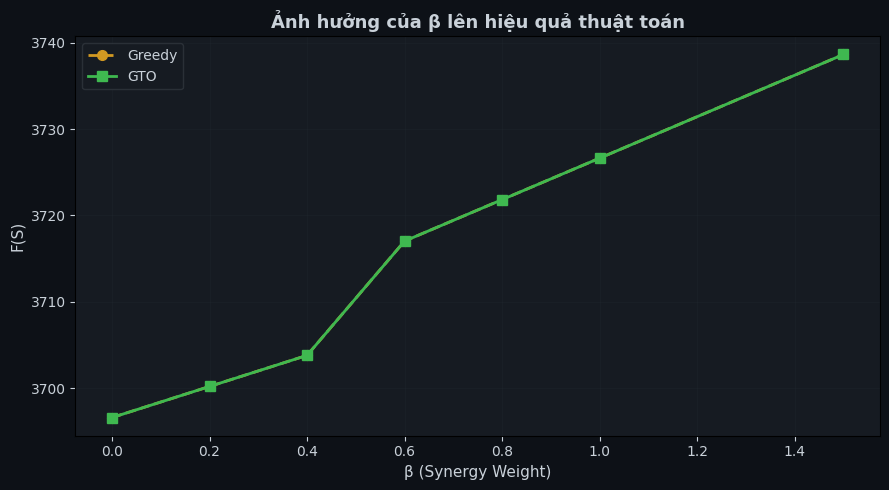

📊  Biểu đồ đã lưu → sensitivity_beta.png


In [17]:

def sensitivity_analysis():
    """Khảo sát ảnh hưởng của β (Synergy weight) lên kết quả."""
    betas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5]
    gto_scores   = []
    grdy_scores  = []

    print("=" * 50)
    print("📈  SENSITIVITY ANALYSIS  –  β (Synergy weight)")
    print("=" * 50)

    for b in betas:
        c = Config(beta=b, gto_max_iter=15, random_trials=30)
        city_ = CityGrid(c)
        rf    = GlobalReward(city_, c)

        # Greedy
        ga = GreedyAgent(city_, c)
        _, gf = ga.optimize()

        # GTO
        gto = GTOAgent(city_, c)
        gto_S, _ = gto.optimize()
        gtof = rf.compute(gto_S)

        gto_scores.append(gtof)
        grdy_scores.append(gf)
        print(f"  β = {b:.1f}  │  Greedy = {gf:.1f}  │  GTO = {gtof:.1f}  │  "
              f"Δ = {gtof - gf:+.1f}")

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="#0d1117")
    ax.set_facecolor("#161b22")
    ax.plot(betas, grdy_scores, "o--", color="#d29922", lw=2,
            markersize=7, label="Greedy")
    ax.plot(betas, gto_scores, "s-", color="#3fb950", lw=2,
            markersize=7, label="GTO")
    ax.fill_between(betas, grdy_scores, gto_scores,
                    alpha=0.15, color="#3fb950")
    ax.set_xlabel("β (Synergy Weight)", color="#c9d1d9", fontsize=11)
    ax.set_ylabel("F(S)", color="#c9d1d9", fontsize=11)
    ax.set_title("Ảnh hưởng của β lên hiệu quả thuật toán",
                 color="#c9d1d9", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, facecolor="#161b22", edgecolor="#30363d",
              labelcolor="#c9d1d9")
    ax.grid(True, alpha=0.15, color="#30363d")
    ax.tick_params(colors="#c9d1d9")
    plt.tight_layout()
    plt.savefig("sensitivity_beta.png", dpi=150, facecolor="#0d1117",
                bbox_inches="tight")
    plt.show()
    print("📊  Biểu đồ đã lưu → sensitivity_beta.png")


sensitivity_analysis()

In [21]:

print("""
╔══════════════════════════════════════════════════════════════╗
║           📖  TÓM TẮT LÝ THUYẾT  –  GLOBAL RL             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Bài toán:                                                   ║
║    max  F(τ)  s.t.  τ là quỹ đạo hợp lệ trong MDP          ║
║    F(τ) = α·Coverage(τ) + β·Synergy(τ) − γ·Penalty(τ)      ║
║                                                              ║
║  Khác biệt với RL chuẩn:                                    ║
║    RL chuẩn:  max Σ r(sₜ, aₜ)   (phần thưởng cộng dồn)    ║
║    Global RL: max F(τ)           (phần thưởng toàn cục)     ║
║                                                              ║
║  Kỹ thuật Semi-gradient:                                     ║
║    1. Tại nghiệm hiện tại S₀, tính modular lower bound:    ║
║       m(S) = const + Σ w(loc) · 𝟙[loc ∈ S]                 ║
║       sao cho m(S) ≤ F(S) ∀S  và  m(S₀) = F(S₀)            ║
║                                                              ║
║    2. w(loc) = lợi ích biên (marginal gain/loss)            ║
║       · loc ∈ S₀:  w = F(S₀) − F(S₀ \\ {loc})              ║
║       · loc ∉ S₀:  w = F(S₀ ∪ {loc}) − F(S₀)              ║
║                                                              ║
║    3. Giải bài toán modular → chọn top-H theo w            ║
║    4. Lặp lại cho đến hội tụ                                 ║
║                                                              ║
║  Đảm bảo:                                                    ║
║    · F không bao giờ giảm qua các vòng lặp (monotone)      ║
║    · Hội tụ đến nghiệm tối ưu cục bộ                        ║
║    · Submodular: đảm bảo xấp xỉ (1 − 1/e) ≈ 63%           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           📖  TÓM TẮT LÝ THUYẾT  –  GLOBAL RL             ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Bài toán:                                                   ║
║    max  F(τ)  s.t.  τ là quỹ đạo hợp lệ trong MDP          ║
║    F(τ) = α·Coverage(τ) + β·Synergy(τ) − γ·Penalty(τ)      ║
║                                                              ║
║  Khác biệt với RL chuẩn:                                    ║
║    RL chuẩn:  max Σ r(sₜ, aₜ)   (phần thưởng cộng dồn)    ║
║    Global RL: max F(τ)           (phần thưởng toàn cục)     ║
║                                                              ║
║  Kỹ thuật Semi-gradient:                                     ║
║    1. Tại nghiệm hiện tại S₀, tính modular lower bound:    ║
║       m(S) = const + Σ w(loc) · 𝟙[loc ∈ S]                 ║
║       sao cho m(S) ≤ F(S) ∀S  và  m(S₀)